Distribution des True Probas : min=0.019, max=0.935, mean=nan
--- RÉSULTATS DE L'AJUSTEMENT (FITTING) ---
Modèle des Gains (Degré 3) : Gain = -244.3*p³ + 497.7*p² + -460.5*p + 206.3
-> RMSE Gains : ± 9.75 points (Écart-type du bruit pour Monte Carlo)
Modèle de la Foule         : Crowd = 1.60 * p^1.51 (plafonné à 1.0)
-> RMSE Foule : ± 8.04 % (Écart-type du bruit pour Monte Carlo)



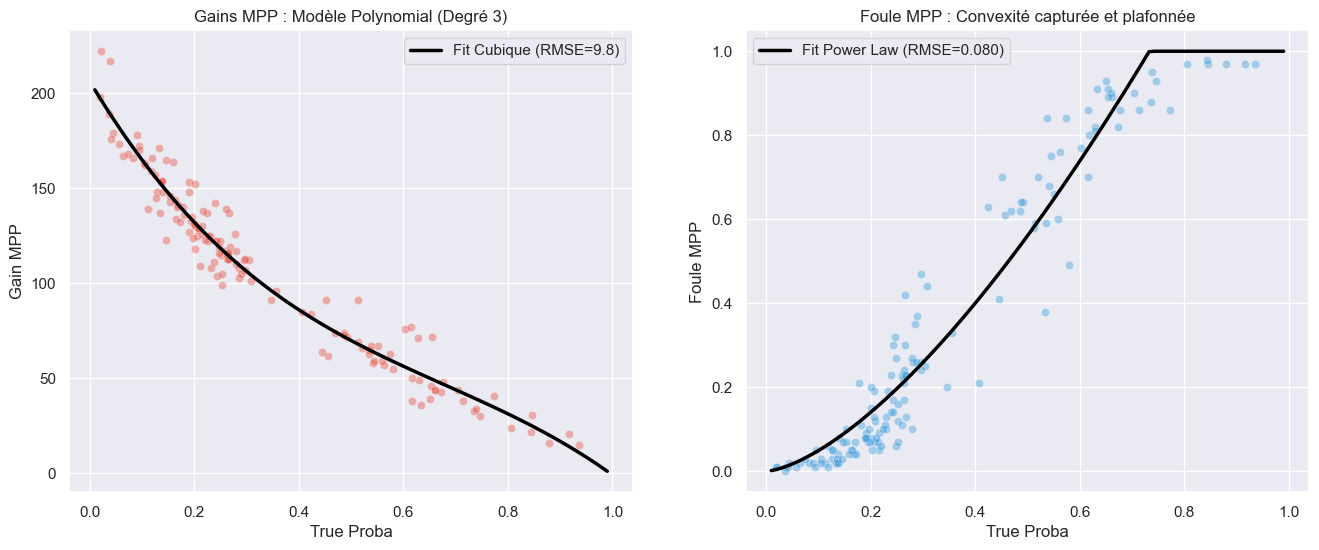

--- SIMULATEUR D'IMPUTATION (MATCH MANQUANT) ---
Pour un Gain MPP de 12  pts -> Proba = 93.0% | Foule = 100.0% | EV = 11.2
Pour un Gain MPP de 40  pts -> Proba = 73.3% | Foule = 99.9% | EV = 29.3
Pour un Gain MPP de 95  pts -> Proba = 35.3% | Foule = 33.1% | EV = 33.5
Pour un Gain MPP de 150 pts -> Proba = 14.3% | Foule =  8.4% | EV = 21.4
Pour un Gain MPP de 200 pts -> Proba =  1.4% | Foule =  0.2% | EV = 2.8

--- TRAQUE DES ANOMALIES (p < 0.1 et Gain atypique) ---
10 matchs suspects détectés avec un très fort Outsider (< 10%).


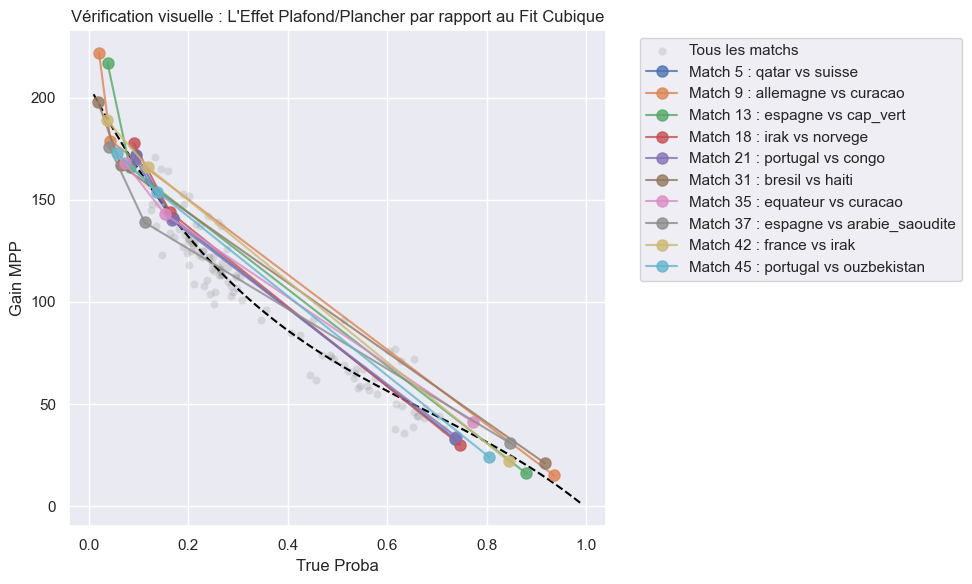

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from pathlib import Path
import sys

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['figure.dpi'] = 100

# Import de ton module core
sys.path.append(str(Path.cwd().parent))
from mpp_project.core import load_tournament_data

# --- 1. CHARGEMENT ET PRÉPARATION ---
data_path_csv = Path.cwd().parent / "data" / "CDM_2026.csv"
df, true_probas, mpp_gains, crowd_repartitions = load_tournament_data(data_path_csv)

X_probas = true_probas.flatten()
print(f"Distribution des True Probas : min={min(X_probas):.3f}, max={max(X_probas):.3f}")
Y_gains = mpp_gains.flatten()
Y_crowd = crowd_repartitions.flatten()

# Filtrage global des données valides
valid_mask = (X_probas > 0) & (~np.isnan(X_probas)) & (~np.isnan(Y_gains))
X_probas = X_probas[valid_mask]
Y_gains = Y_gains[valid_mask]
Y_crowd = Y_crowd[valid_mask]

# --- 2. MODÉLISATION MATHÉMATIQUE (Cubique & Power Law) ---

def func_gain_cubic(p, a, b, c, d):
    """Modèle polynomial de degré 3 pour épouser la courbe en 'S' des gains"""
    return a * (p**3) + b * (p**2) + c * p + d

def func_crowd(p, a, b):
    """Loi de puissance pour la foule"""
    return a * (p ** b)

# Fitting des Gains (Global)
popt_gains, _ = curve_fit(func_gain_cubic, X_probas, Y_gains)
a_g, b_g, c_g, d_g = popt_gains

# Fitting de la Foule (Sans l'effet plafond p > 0.8)
mask_crowd_fit = X_probas <= 0.8
popt_crowd, _ = curve_fit(func_crowd, X_probas[mask_crowd_fit] + 1e-5, Y_crowd[mask_crowd_fit])
a_c, b_c = popt_crowd

def predict_crowd(p, a, b):
    """Prédiction avec plafonnement physique à 1.0 (100%)"""
    return min(1.0, max(0.0, a * (p ** b)))

# Vectorisation pour l'affichage et les calculs matriciels
predict_crowd_vec = np.vectorize(lambda x: predict_crowd(x, *popt_crowd))

# --- CALCUL DES ÉCARTS-QUADRATIQUES MOYENS (RMSE) ---
# RMSE = sqrt( mean( (y_true - y_pred)^2 ) )
rmse_gains = np.sqrt(np.mean((Y_gains - func_gain_cubic(X_probas, *popt_gains))**2))
rmse_crowd = np.sqrt(np.mean((Y_crowd - predict_crowd_vec(X_probas))**2))

print("--- RÉSULTATS DE L'AJUSTEMENT (FITTING) ---")
print(f"Modèle des Gains (Degré 3) : Gain = {a_g:.1f}*p³ + {b_g:.1f}*p² + {c_g:.1f}*p + {d_g:.1f}")
print(f"-> RMSE Gains : ± {rmse_gains:.2f} points (Écart-type du bruit pour Monte Carlo)")
print(f"Modèle de la Foule         : Crowd = {a_c:.2f} * p^{b_c:.2f} (plafonné à 1.0)")
print(f"-> RMSE Foule : ± {rmse_crowd*100:.2f} % (Écart-type du bruit pour Monte Carlo)\n")


# --- 3. AFFICHAGE DES RÉSULTATS ---
x_line = np.linspace(0.01, 0.99, 100)
y_line_gains = func_gain_cubic(x_line, *popt_gains)
y_line_crowd = predict_crowd_vec(x_line)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique Gains
sns.scatterplot(x=X_probas, y=Y_gains, alpha=0.4, color="#e74c3c", ax=axes[0])
axes[0].plot(x_line, y_line_gains, color="black", linewidth=2.5, label=f"Fit Cubique (RMSE={rmse_gains:.1f})")
axes[0].set_title("Gains MPP : Modèle Polynomial (Degré 3)")
axes[0].set_xlabel("True Proba")
axes[0].set_ylabel("Gain MPP")
axes[0].legend()

# Graphique Foule
sns.scatterplot(x=X_probas, y=Y_crowd, alpha=0.4, color="#3498db", ax=axes[1])
axes[1].plot(x_line, y_line_crowd, color="black", linewidth=2.5, label=f"Fit Power Law (RMSE={rmse_crowd:.3f})")
axes[1].set_title("Foule MPP : Convexité capturée et plafonnée")
axes[1].set_xlabel("True Proba")
axes[1].set_ylabel("Foule MPP")
axes[1].legend()

plt.show()

# --- 4. LE RÉSOLVEUR INVERSE (L'OUTIL D'IMPUTATION) ---
def estimate_proba_from_gain(gain, a=a_g, b=b_g, c=c_g, d=d_g):
    """
    Retrouve 'p' en cherchant les racines du polynôme :
    a*p³ + b*p² + c*p + (d - Gain) = 0
    """
    coeffs = [a, b, c, d - gain]
    racines = np.roots(coeffs)
    racines_reelles = racines.real[abs(racines.imag) < 1e-5]
    valid_p = [r for r in racines_reelles if 0.0 <= r <= 1.0]
    
    if len(valid_p) > 0:
        return max(0.01, min(0.99, valid_p[0]))
    else:
        return 0.99 if gain < 20 else 0.01

# --- 5. TEST DU SIMULATEUR ---
print(f"--- SIMULATEUR D'IMPUTATION (MATCH MANQUANT) ---")
test_gains = [12, 40, 95, 150, 200] 

for g in test_gains:
    p_est = estimate_proba_from_gain(g)
    c_est = predict_crowd(p_est, *popt_crowd)
    ev_est = p_est * g
    print(f"Pour un Gain MPP de {g:<3} pts -> Proba = {p_est*100:4.1f}% | Foule = {c_est*100:4.1f}% | EV = {ev_est:.1f}")

# --- 6. ANALYSE DES ANOMALIES (Le Plafond Bookmaker/MPP) ---
print("\n--- TRAQUE DES ANOMALIES (p < 0.1 et Gain atypique) ---")

seuil_proba = 0.1
anomalies_idx = []

for idx, row in df.iterrows():
    probas_match = [row.get('true_proba_1', np.nan), row.get('true_proba_N', np.nan), row.get('true_proba_2', np.nan)]
    if any(p < seuil_proba for p in probas_match if not pd.isna(p)):
        anomalies_idx.append(idx)

df_anomalies = df.loc[anomalies_idx]
print(f"{len(df_anomalies)} matchs suspects détectés avec un très fort Outsider (< 10%).")

if len(df_anomalies) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.scatterplot(x=X_probas, y=Y_gains, alpha=0.2, color="gray", ax=ax, label="Tous les matchs")
    ax.plot(x_line, y_line_gains, color="black", linewidth=1.5, linestyle="--")
    
    for _, row in df_anomalies.iterrows():
        p_match = [row['true_proba_1'], row['true_proba_N'], row['true_proba_2']]
        g_match = [row['gain_mpp_1'], row['gain_mpp_N'], row['gain_mpp_2']]
        
        ax.plot(p_match, g_match, marker='o', markersize=8, linewidth=1.5, alpha=0.8, 
                label=f"Match {row['match_id']} : {row['team_A']} vs {row['team_B']}")
        
    ax.set_title("Vérification visuelle : L'Effet Plafond/Plancher par rapport au Fit Cubique")
    ax.set_xlabel("True Proba")
    ax.set_ylabel("Gain MPP")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()